In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [86]:
df = pd.read_csv("data/player_data_COMPLETE.csv")

Filtramos para que nos salgan únicamente los jugadores de la posición que queremos

In [87]:
df_fb = df[df["main_position"].isin(["LWB", "RWB"])].copy()
df_clustering = df_fb[df_fb["low_minutes_flag"] == False].copy()

Selección de métricas

In [88]:
features_clustering = [
    # ataque
    "crosses_avg",
    "assists_avg",
    "goals_avg",
    
    # progresión
    "real_progression",
    
    # defensa
    "interceptions_avg",
    "duels_won_avg",
    "successful_defensive_actions_avg"

]

X = df_clustering[features_clustering].fillna(0)

Escalado

In [89]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [90]:
df_scaled = pd.DataFrame(X_scaled, columns=features_clustering)
print("\nDatos estandarizados:")
print(df_scaled.head())


Datos estandarizados:
   crosses_avg  assists_avg  goals_avg  real_progression  interceptions_avg  \
0    -0.676101    -1.052862  -0.879202         -1.130222           0.468239   
1    -0.904042    -1.052862  -0.879202         -1.066600          -2.090503   
2     0.140689     0.575294  -0.061693          1.048802          -1.856772   
3     2.619551     1.877818  -0.879202         -0.281940           0.062285   
4    -1.046505     0.683837   2.857980          0.502720          -1.020260   

   duels_won_avg  successful_defensive_actions_avg  
0       0.864263                          1.277241  
1       1.976775                         -1.205258  
2      -0.063761                         -2.340720  
3       1.373075                          0.169990  
4      -0.720952                         -0.979577  


PCA: Reducción de dimensionalidad

In [91]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)

[0.32124096 0.2392804  0.13798116]


In [92]:
n_components = 3
pca_clustering = pd.DataFrame(data=X_pca, columns=[f'PC{i}' for i in range(1, n_components+1)])
print("\nComponentes principales:")
print(pca_clustering.head())


Componentes principales:
        PC1       PC2       PC3
0 -2.263744 -0.748111  0.035770
1  0.102258 -2.137311  1.008326
2  2.778689 -0.246859 -0.005250
3  0.304765  2.427256  0.957040
4  2.211748 -1.118828  1.309504


C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the

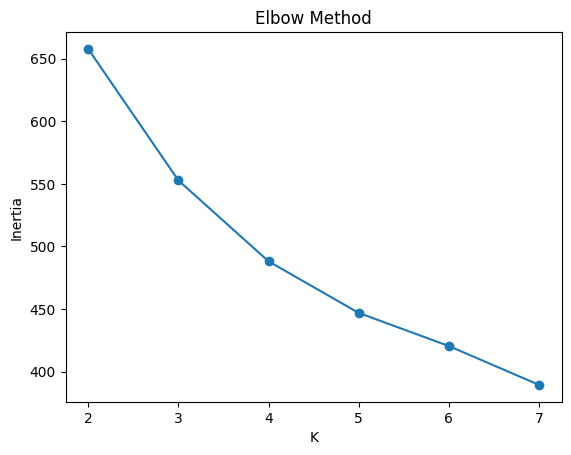

In [93]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

import matplotlib.pyplot as plt
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

In [94]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_clustering["cb_cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [95]:
cluster_profile = df_clustering.groupby("cb_cluster")[features_clustering].mean()
print(cluster_profile)

            crosses_avg  assists_avg  goals_avg  real_progression  \
cb_cluster                                                          
0              2.914417     0.069206   0.256760          7.501356   
1              2.674045     0.075946   0.046216          7.917169   
2              3.737902     0.175272   0.068908         10.150857   
3              2.247429     0.056571   0.039429          6.809143   

            interceptions_avg  duels_won_avg  successful_defensive_actions_avg  
cb_cluster                                                                      
0                    2.868533       7.336716                          6.110180  
1                    4.227696       8.565417                          8.748877  
2                    3.289112       6.690923                          6.500487  
3                    3.146000       6.876658                          6.654571  


In [96]:
cols_show = ["name", "market_value", "minutes_on_field", "cb_cluster"]

df_cb_view = df_clustering[cols_show].sort_values(
    ["cb_cluster", "market_value"],
    ascending=[True, False]
)

for c in sorted(df_clustering["cb_cluster"].unique()):
    print(f"\n--- CLUSTER {c} ---")
    display(df_cb_view[df_cb_view["cb_cluster"] == c].head(10))


--- CLUSTER 0 ---


,name,market_value,minutes_on_field,cb_cluster
2775,D. Dumfries,24000000.0,2349,0
1403,A. Diallo,18000000.0,2406,0
1302,Rodrigo Gomes,12000000.0,2165,0
3534,A. Saelemaekers,12000000.0,2442,0
1192,Geny Catamo,10000000.0,2064,0
1236,T. Buchanan,8000000.0,1411,0
1530,J. Kamiński,6000000.0,1692,0
3561,S. Birindelli,3500000.0,1364,0
1029,T. Le Bris,2000000.0,745,0
1806,D. Lazović,1500000.0,653,0



--- CLUSTER 1 ---


,name,market_value,minutes_on_field,cb_cluster
1514,R. Aït-Nouri,35000000.0,2503,1
2939,N. Mazraoui,30000000.0,2378,1
3838,T. Mitchell,25000000.0,3526,1
3627,D. Muñoz,23000000.0,3749,1
2727,R. Gosens,12000000.0,2550,1
3745,M. Bard,12000000.0,2731,1
1217,D. Rensch,10000000.0,681,1
1644,F. Parisi,9500000.0,1241,1
692,T. Rothe,8000000.0,1759,1
1534,M. Araújo,7500000.0,1947,1



--- CLUSTER 2 ---


,name,market_value,minutes_on_field,cb_cluster
2470,F. Dimarco,50000000.0,2220,2
2220,Álex Grimaldo,45000000.0,2697,2
1633,Yan Couto,25000000.0,1186,2
3109,J. Ryerson,20000000.0,2182,2
3218,Dodô,17000000.0,3310,2
3232,R. Bellanova,15000000.0,2650,2
2630,Nuno Santos,14000000.0,1210,2
1529,N. Zalewski,12000000.0,1037,2
2115,J. Clauss,12000000.0,2534,2
851,L. Assignon,10000000.0,2558,2



--- CLUSTER 3 ---


,name,market_value,minutes_on_field,cb_cluster
3044,Diogo Dalot,35000000.0,2673,3
2626,Angeliño,8000000.0,2757,3
3417,D. Köhn,6000000.0,1658,3
1498,M. Pedersen,5500000.0,1694,3
1721,A. Zanoli,5000000.0,1904,3
3804,D. Bradarić,5000000.0,2473,3
1777,M. Darmian,4000000.0,1218,3
2902,Ricardo Mangas,4000000.0,1688,3
1438,Leonardo Lelo,3500000.0,3124,3
1665,K. Lund,3500000.0,807,3


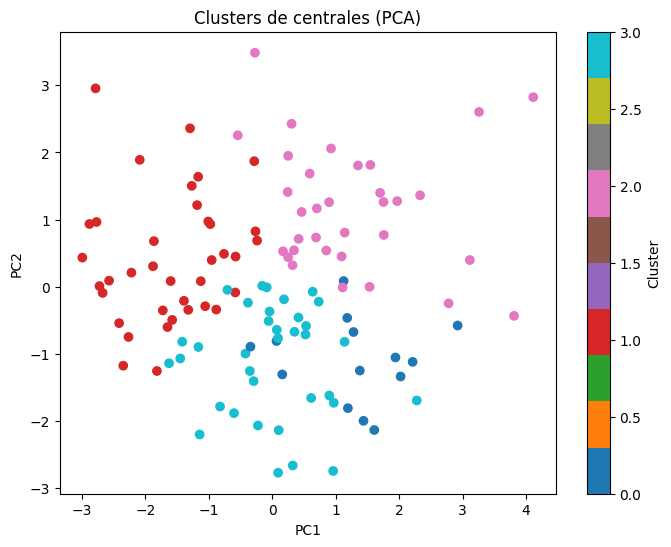

In [97]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df_clustering["cb_cluster"],
    cmap="tab10"
)

plt.title("Clusters de centrales (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(label="Cluster")
plt.show()

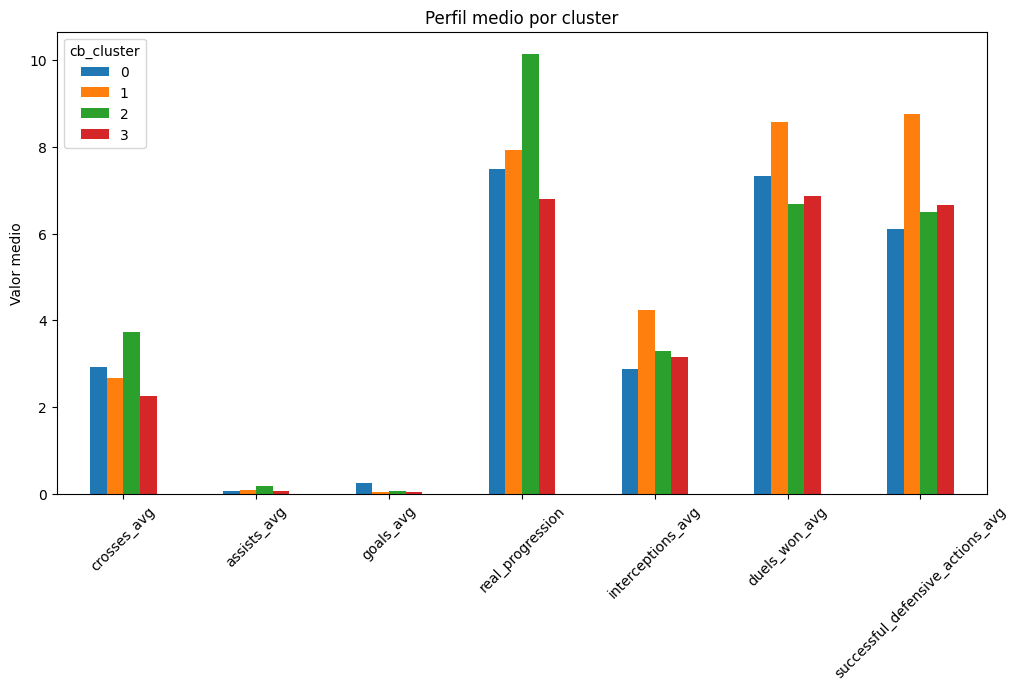

In [98]:
cluster_profile.T.plot(kind="bar", figsize=(12,6))
plt.title("Perfil medio por cluster")
plt.xticks(rotation=45)
plt.ylabel("Valor medio")
plt.show()

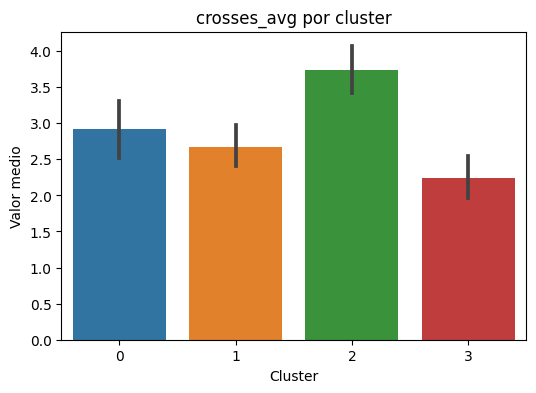

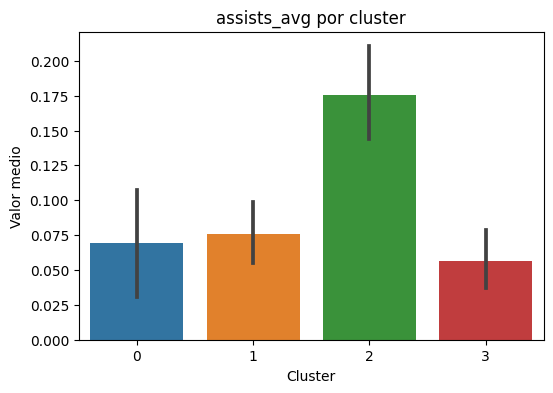

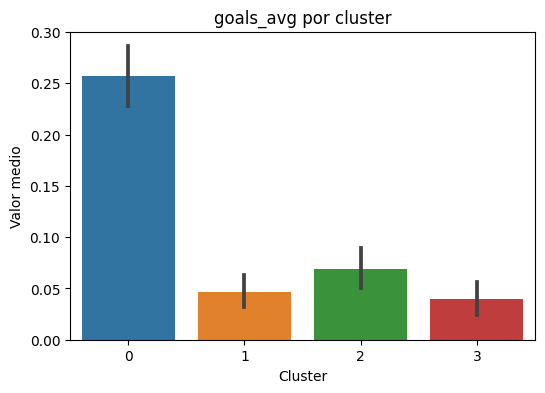

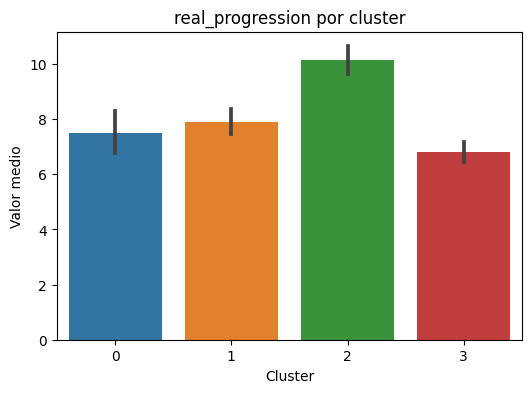

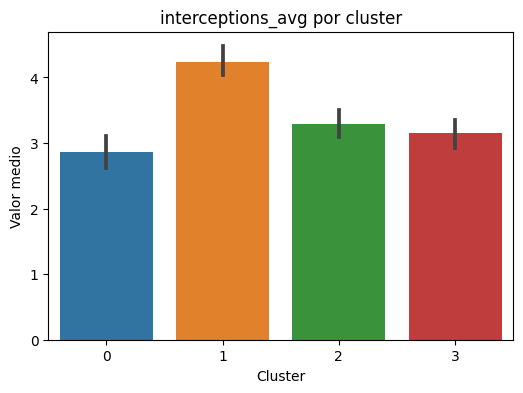

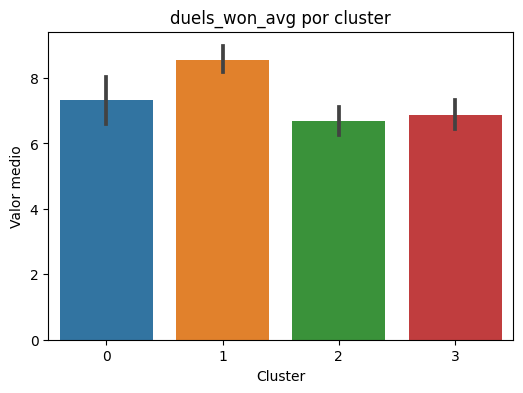

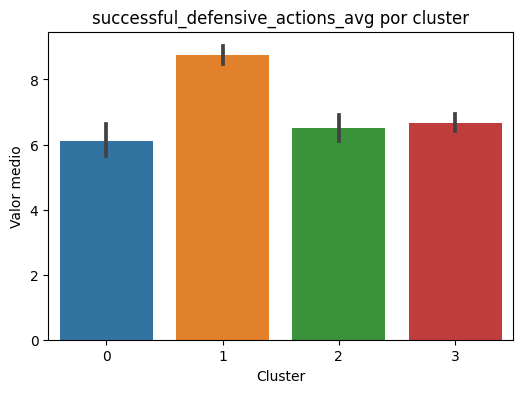

In [99]:
for col in features_clustering:
    
    plt.figure(figsize=(6,4))
    
    sns.barplot(
        x="cb_cluster",
        y=col,
        data=df_clustering
    )
    
    plt.title(f"{col} por cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Valor medio")
    
    plt.show()

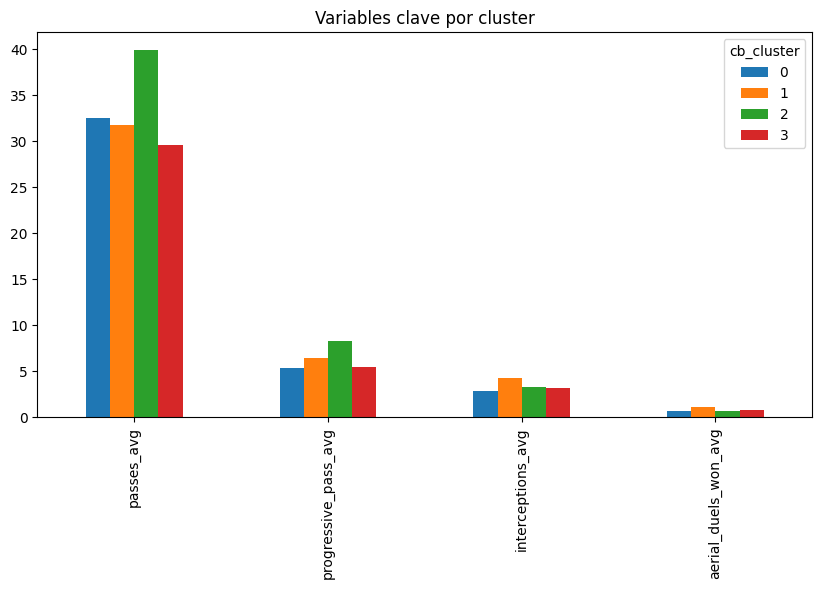

In [100]:
key_vars = [
    "passes_avg",
    "progressive_pass_avg",
    "interceptions_avg",
    "aerial_duels_won_avg"
]

df_clustering.groupby("cb_cluster")[key_vars].mean().T.plot(kind="bar", figsize=(10,5))
plt.title("Variables clave por cluster")
plt.show()

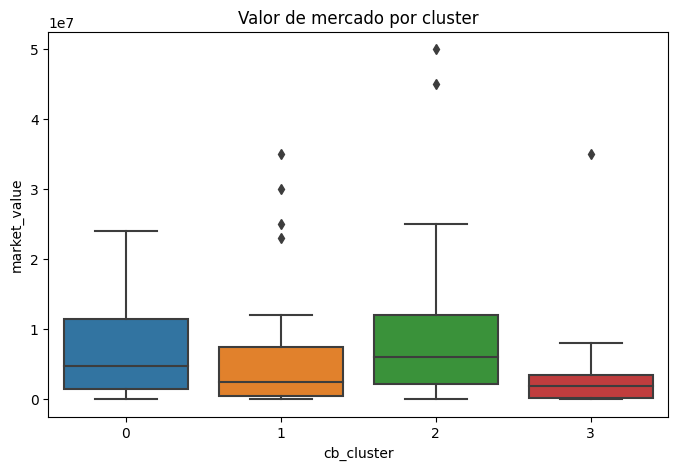

In [101]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cb_cluster", y="market_value", data=df_clustering)
plt.title("Valor de mercado por cluster")
plt.show()

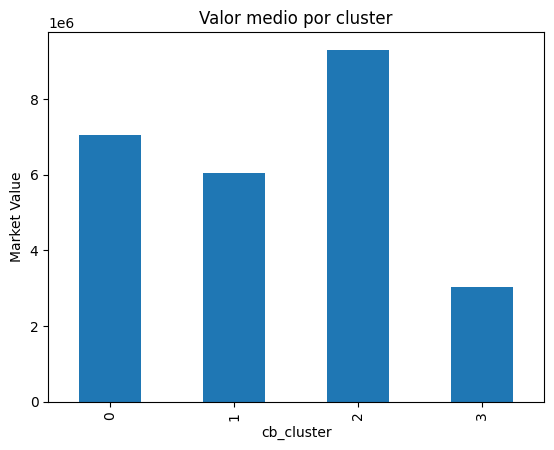

In [102]:
df_clustering.groupby("cb_cluster")["market_value"].mean().plot(kind="bar")

plt.title("Valor medio por cluster")
plt.ylabel("Market Value")
plt.show()

In [103]:
loadings = pd.DataFrame(
    pca.components_,
    columns=features_clustering,
    index=["PC1", "PC2", "PC3"]
)

display(loadings)

,crosses_avg,assists_avg,goals_avg,real_progression,interceptions_avg,duels_won_avg,successful_defensive_actions_avg
PC1,0.243430,0.301001,0.283148,0.224726,-0.511379,-0.330341,-0.590620
PC2,0.550162,0.422973,-0.169008,0.567288,0.299062,0.102069,0.261115
PC3,0.059048,0.161472,0.617276,-0.085087,-0.171161,0.735843,0.106813


cluster_labels = {
    0: "Attacking full-back (goal threat)",
    1: "Creative full-back",
    2: "Low-impact full-back",
    3: "Defensive full-back"
}


In [104]:
cb_labels = {
    0: "Ball-stealing CB",
    1: "Ball-playing CB",
    2: "Aerial dominant CB",
    3: "Low-impact CB"
}

fb_labels = {
    0: "Attacking full-back (goal threat)",
    1: "Creative full-back",
    2: "Low-impact full-back",
    3: "Defensive full-back"
}

wb_labels = {
    0: "Goal-scoring wing-back",
    1: "Defensive wing-back",
    2: "Attacking wing-back",
    3: "Low-impact wing-back"
}

mf_labels = {
    0: "Attacking midfielder",
    1: "Low-impact midfielder",
    2: "Deep-lying playmaker",
    3: "Ball-winning midfielder"
}

w_labels = {
    0: "Dribbler winger",
    1: "Low-impact winger",
    2: "Defensive winger",
    3: "Goal-scoring winger"
}

fw_labels = {
    0: "Target man",
    1: "Pressing forward",
    2: "Creative forward",
    3: "Poacher"
}

gk_labels = {
    0: "Low-performing GK",
    1: "Shot-stopper GK",
    2: "Ball-playing GK",
    3: "Low-impact GK"
}

def assign_role(row):
  
    return wb_labels.get(row["cb_cluster"])


df_clustering["player_role"] = df_clustering.apply(assign_role, axis=1)

In [105]:
df_clustering[["id", "name", "cb_cluster", "player_role"]].to_csv("clustering/data/wb_clusters.csv", index=False)